Univers PEA : 400 actions retenues, toutes devises
Backtest: 2007-01-31 -> 2026-08-31 ; capital: 100,000 EUR
   strategie     cagr  rendement_moyen_annualise  volatilite   sharpe  max_drawdown
Momentum EUR 0.277468                   0.273844    0.235475 1.162944     -0.233749
Secteurs EUR 0.176734                   0.180615    0.185699 0.972622     -0.264975
   Mix 50/50 0.234787                   0.227230    0.172704 1.315716     -0.209378

Allocation:
  support      sector currency  poids_cible   prix_eur  quantite  montant_eur  poids_reel
  REP.MC      Energy      EUR        0.225  27.250000     825.0 22481.250000    0.224812
 BMPS.MI  Financials      EUR        0.100  11.572000     864.0  9998.207611    0.099982
NESTE.HE      Energy      EUR        0.100  31.879999     313.0  9978.439737    0.099784
 GALP.LS      Energy      EUR        0.125  21.400000     584.0 12497.599777    0.124976
  RBI.VI  Financials      EUR        0.100  63.799999     156.0  9952.799881    0.099528
  TEN.M

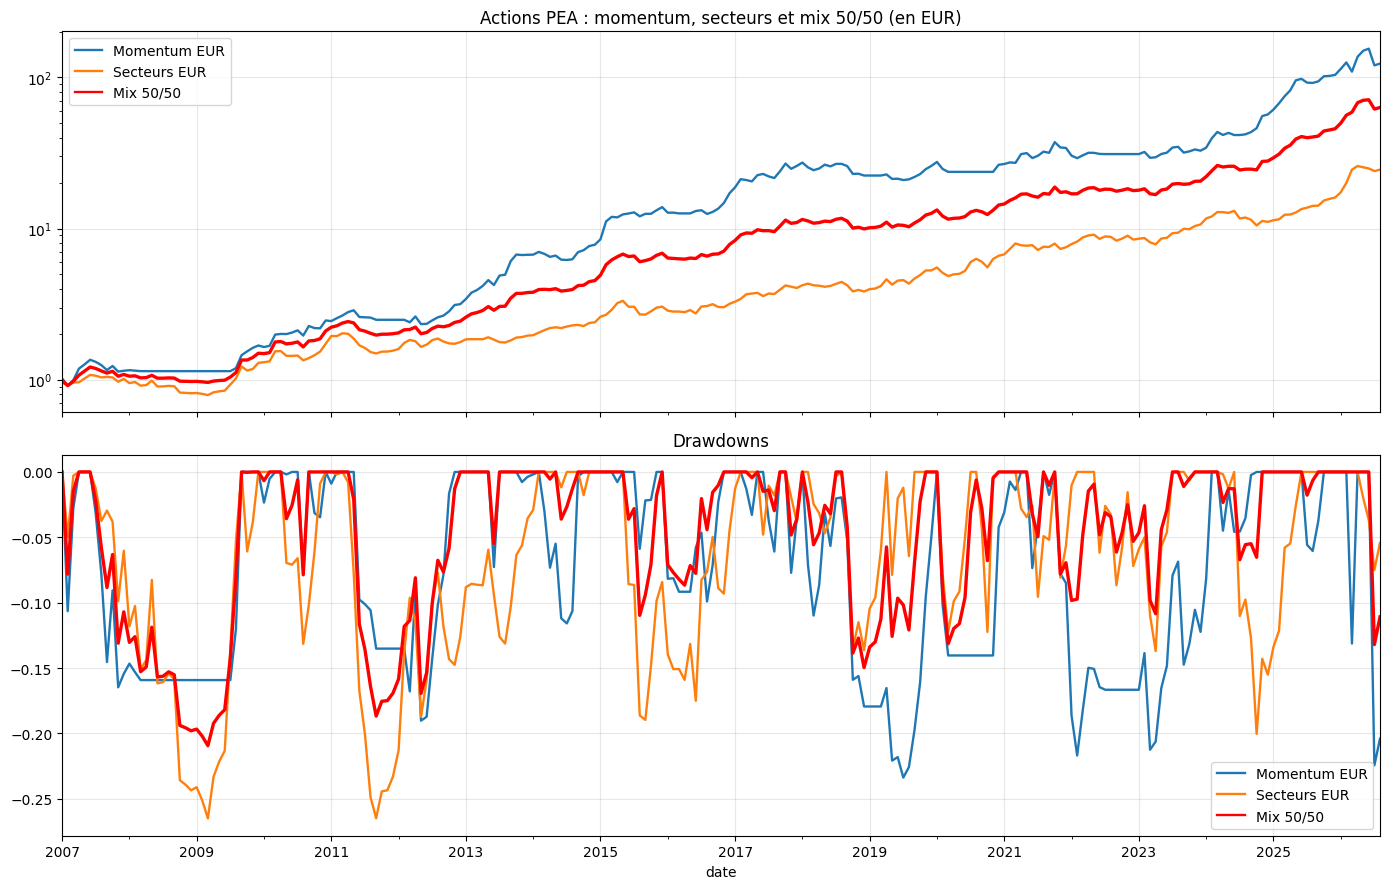

In [2]:
%pip -q install yfinance pandas_market_calendars "toolz>=0.11,<1"

"""UN SEUL fichier a fournir : STOXX600_PEA.csv, a cote de ce script.
Colonnes : symbol, sector, currency ; uniquement des titres eligibles au PEA.
Cours, changes et inflation telecharges automatiquement ; resultats a l'ecran.
Momentum en EUR ; signal sectoriel US en USD ; portefeuilles et paniers en EUR.
Univers date issu du CSV, sans reconstitution historique ; acceptation PEA a confirmer chez le courtier.
"""

from concurrent.futures import ThreadPoolExecutor
from functools import cache
from io import StringIO
from itertools import combinations, islice
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import requests
import yfinance as yf

# Parametres
DATA_START = "2003-01-01"
CAPITAL_EUR = 100_000.0
INPUT_CSV = (Path(__file__).parent if "__file__" in globals() else Path.cwd()) / "STOXX600_PEA.csv"
SECTOR_STOCKS = 4
MOMENTUM_N = 5
PHI_THRESHOLD = 0.10
CORR_MONTHS, CORR_SHORTLIST = 36, 12
MOM_LONG, MOM_SHORT = 12, 4
MIN_COVERAGE = 0.80
ROUNDING, COST_BPS = 0.25, 0.0
GROWTH_WINDOWS, INFLATION_LAGS = (5, 6, 7, 10, 12), (2, 3, 4)
SIGNALS = ["SPY", "XLB", "XLE", "XLF", "XLI", "XLK", "XLP", "XLU", "XLV"]
SECTORS = {"XLE": "Energy", "XLK": "Information Technology",
           "XLU": "Utilities", "XLP": "Consumer Staples"}
FX = "EURUSD=X"


def require(condition, message, error=RuntimeError):
    if not condition:
        raise error(message)


def month_end(data):
    return data.set_axis(pd.to_datetime(data.index).tz_localize(None).to_period("M").to_timestamp("M"))


def numeric(data):
    return data.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)


def yahoo(symbols, interval="1mo", repair=True, **dates):
    data = yf.download(list(dict.fromkeys(symbols)), **dates, interval=interval, auto_adjust=False,
                       actions=repair, repair=repair, multi_level_index=True, group_by="column",
                       ignore_tz=True, progress=False, threads=True, timeout=60)
    require(not data.empty, f"Yahoo vide : {symbols}")
    data = numeric(data)
    return month_end(data) if interval == "1mo" else data.set_axis(pd.to_datetime(data.index).tz_localize(None))


def inflation_history(start):
    def read(code):
        response = requests.get(f"https://api.db.nomics.world/v22/series/FED/H15/{code}",
                                params={"observations": 1, "format": "csv"}, timeout=(5, 30))
        response.raise_for_status()
        series = pd.read_csv(StringIO(response.text), index_col=0).iloc[:, 0]
        series.index = pd.to_datetime(series.index, errors="coerce")
        return pd.to_numeric(series, errors="coerce").dropna().loc[lambda s: ~s.index.duplicated(keep="last")]

    legs = pd.concat(map(read, ("RIFLGFCY05_N.B", "RIFLGFCY05_XII_N.B")), axis=1, join="inner").dropna()
    daily = (legs.iloc[:, 0] - legs.iloc[:, 1]).loc[start:]
    require(not daily.empty, "Historique d'inflation vide")
    monthly = daily.resample("ME").last().rename("T5YIE")
    monthly.attrs["last_date"] = daily.index[-1]
    return monthly


def macro_history(start):
    history = yahoo([*SIGNALS, FX], start=start)
    inflation = inflation_history(start)
    daily = yahoo([*SIGNALS, FX], period="1mo", interval="1d", repair=False)["Close"]
    macro = pd.concat([history["Adj Close"][SIGNALS], history["Close"][FX], inflation], axis=1)
    common = macro.dropna().index.sort_values().unique()
    require(len(common) > 0, "Aucun mois commun aux sources macro")
    month = common[-1].to_period("M")
    last = mcal.get_calendar("NYSE").schedule(
        start_date=month.start_time.date(), end_date=month.end_time.date()).iloc[-1]
    dates = pd.to_datetime([*daily[[*SIGNALS, FX]].apply(pd.Series.last_valid_index), inflation.attrs["last_date"]])
    complete = dates.notna().all() and (dates.normalize() >= last.name).all()
    if complete:
        metadata = yf.Ticker("SPY").get_history_metadata()
        complete = pd.to_datetime(metadata["regularMarketTime"], unit="s", utc=True) >= last.market_close
    common = common if complete else common[:-1]
    require(len(common) > 0, "Aucun mois complet commun aux sources macro")
    macro = macro.reindex(pd.date_range(macro.apply(pd.Series.first_valid_index).max(), common[-1], freq="ME"))
    require(not macro.isna().any().any(), "Donnees macro incompletes")
    return macro


def load_universe(path):
    """Lire l'univers prefiltre PEA ; respecter aussi le statut des anciens CSV."""
    raw = pd.read_csv(path, encoding="utf-8-sig", dtype=str, keep_default_na=False)
    raw.columns = raw.columns.str.strip().str.lower()
    fields = ["symbol", "sector", "currency"]
    require(set(fields).issubset(raw), "Colonnes attendues : symbol, sector, currency", ValueError)
    raw = raw.apply(lambda s: s.str.strip()).assign(symbol=lambda d: d.symbol.str.upper())
    if "pea" in raw:  # Ancien format : un refus ou statut inconnu prime sur les doublons.
        raw["pea"] = raw.pea.str.upper().isin(["OUI", "YES", "TRUE", "1"])
        raw = raw.loc[raw.groupby("symbol").pea.transform("all")]
    universe = raw[fields].drop_duplicates()
    require(not universe.empty, "Univers PEA vide")
    require(universe.ne("").all().all(), "Symbole, secteur ou devise manquant", ValueError)
    universe = universe.set_index("symbol", verify_integrity=True)
    print(f"Univers PEA : {len(universe)} actions retenues, toutes devises")
    return universe


def stock_prices(universe, dates):
    """Telecharger, verifier la devise, puis convertir tous les cours en EUR."""
    def download(row):
        try:
            ticker = yf.Ticker(row.Index)
            history = ticker.history(start=DATA_START, interval="1mo", auto_adjust=False, repair=True, timeout=60)
            currency = ticker.get_history_metadata().get("currency", "")
            # Les metadonnees suivent la reparation : ne pas reconvertir des GBP deja normalises.
            currency, unit = ("GBP", 0.01) if currency in ("GBp", "GBX") else (currency.upper(), 1)
            expected = "GBP" if row.currency in ("GBp", "GBX") else row.currency.upper()
            require(currency and currency == expected, "Devise Yahoo absente ou differente du CSV")
            prices = month_end(numeric(history[["Close", "Adj Close"]]).astype(float) * unit)
            prices = prices.where(prices.gt(0)).loc[lambda d: ~d.index.duplicated(keep="last")]
            require(prices["Adj Close"].notna().sum() >= 2, "Historique insuffisant")
            return row.Index, prices
        except Exception as exc:
            print(f"  {row.Index} ignore : {exc}")

    with ThreadPoolExecutor(max_workers=8) as pool:
        histories = dict(filter(None, pool.map(download, universe.itertuples())))
    require(histories, "Aucun cours action disponible")
    require(len(histories) / len(universe) >= MIN_COVERAGE, "Couverture Yahoo insuffisante")
    active = universe.loc[list(histories)].assign(
        currency=lambda d: d.currency.replace({"GBp": "GBP", "GBX": "GBP"}).str.upper())
    prices = pd.concat(histories, axis=1).reindex(dates)
    currencies = prices.columns.get_level_values(0).map(active.currency)
    pairs = {f"EUR{c}=X": c for c in sorted(set(currencies) - {"EUR"})}
    rates = pd.DataFrame({"EUR": 1.0}, index=dates)
    if pairs:
        rates = rates.join(yahoo(list(pairs), start=DATA_START, repair=False)["Close"].rename(columns=pairs))
    rates = rates.reindex(columns=currencies).set_axis(prices.columns, axis=1)  # Unites locales pour 1 EUR.
    require(((np.isfinite(rates) & rates.gt(0)) | prices.isna()).all().all(), "Taux de change absent, incomplet ou invalide")
    prices = prices / rates
    return prices.xs("Adj Close", axis=1, level=1), prices.xs("Close", axis=1, level=1), active


def rounded(weights):
    """Plus forts restes ; egalites departagees par le minimum de changements."""
    units = round(1 / ROUNDING)
    values = np.column_stack([weights, (1 - weights.sum(axis=1)).clip(lower=0)])
    scaled = values * units / values.sum(axis=1, keepdims=True)
    integer = np.floor(scaled).astype(int)
    remainders = np.round(scaled - integer, 12)
    previous = np.r_[np.zeros(weights.shape[1], int), units]
    for row, remainder in zip(integer, remainders):
        trade = abs(row + 1 - previous) - abs(row - previous)
        row[np.lexsort((trade, -remainder))[:units - row.sum()]] += 1
        previous = row
    return pd.DataFrame(integer[:, :-1] / units, index=weights.index, columns=weights.columns)


def sector_signal(etfs, inflation):
    returns = etfs.pct_change(fill_method=None)
    positive = 0.5 * returns.XLE + (returns.XLI + returns.XLF + returns.XLB) / 6
    negative = (returns.XLU + returns.XLV + returns.XLP) / 3
    ratio = (1 + positive).cumprod() / (1 + negative).cumprod()
    averages = pd.DataFrame({n: etfs.SPY.rolling(n).mean() for n in GROWTH_WINDOWS})
    votes = {}
    for lag in INFLATION_LAGS:
        old = inflation.shift(lag)
        x = np.arange(lag + 1, dtype=float) - lag / 2
        trend = ratio.rolling(lag + 1).apply(lambda y: float(x @ y), raw=True)
        rising = (inflation > old) | (trend > 0)
        known = inflation.notna() & ((inflation <= 2) | rising | (old.notna() & trend.notna()))
        votes[lag] = ((inflation > 2) & rising).astype(float).where(known)
    bull = averages.lt(etfs.SPY, axis=0).mean(axis=1).where(averages.notna().all(axis=1))
    high = pd.DataFrame(votes).mean(axis=1, skipna=False)
    defensive = 0.5 * (1 - bull) * (1 - high)
    weights = pd.DataFrame({"XLE": bull * high, "XLK": bull * (1 - high), "XLU": (1 - bull) * high,
                            "XLP": defensive, "CASH_EUR": defensive})
    return rounded(weights.fillna(0))  # Signal incomplet : aucune position.


@cache
def basket_indices(count, size):
    return np.asarray(list(combinations(range(count), size)))


def best_basket(returns, benchmark):
    returns = returns.dropna(axis=1).sort_index(axis=1).loc[:, lambda d: d.nunique() > 1]
    if benchmark.isna().any() or benchmark.nunique() < 2:
        return []
    shortlist = sorted(returns.corrwith(benchmark).dropna().nlargest(CORR_SHORTLIST).index)
    if len(shortlist) < SECTOR_STOCKS:
        return []
    choices = basket_indices(len(shortlist), SECTOR_STOCKS)
    baskets = pd.DataFrame(returns[shortlist].to_numpy()[:, choices].mean(axis=2), index=returns.index)
    scores = baskets.corrwith(benchmark)
    return [shortlist[i] for i in choices[scores.idxmax()]] if scores.notna().any() else []


def sector_targets(stock_returns, sector_etfs, universe, weights):
    stock_returns = stock_returns.reindex(sector_etfs.index)
    etf_returns = sector_etfs.pct_change(fill_method=None)
    target = pd.DataFrame(0.0, index=stock_returns.index, columns=stock_returns.columns)
    selectors = pd.DataFrame(False, index=stock_returns.index, columns=SECTORS)
    for alias, sector in SECTORS.items():
        members = stock_returns.columns.intersection(universe.index[universe.sector.eq(sector)]).sort_values()
        for window in islice(stock_returns[members].rolling(CORR_MONTHS), CORR_MONTHS, None):
            date = window.index[-1]
            chosen = best_basket(window, etf_returns.loc[window.index, alias])
            if chosen:
                target.loc[date, chosen] += (1 / SECTOR_STOCKS) * weights.at[date, alias]
                selectors.at[date, alias] = True
    ready = (weights[list(SECTORS)].eq(0) | selectors).all(axis=1) & np.isclose(target.sum(axis=1) + weights.CASH_EUR, 1)
    return target.where(ready, 0, axis=0), ready, selectors


def momentum_targets(prices):
    # Formule du PDF : (cours - moyenne mobile) / moyenne mobile.
    averages = (prices.rolling(n).mean() for n in (MOM_LONG, MOM_SHORT))
    long, short = ((prices - average) / average for average in averages)
    valid = long.notna() & prices.gt(0)
    direction = np.sign(long).where(valid, 0)
    count, eligible = valid.sum(axis=1), prices.notna().cumsum().ge(MOM_LONG).sum(axis=1)
    phi = direction.sum(axis=1) / direction.abs().sum(axis=1).replace(0, np.nan)
    phi = phi.where((count / eligible.replace(0, np.nan) >= MIN_COVERAGE) & (count >= MOMENTUM_N))
    candidates = long.where(long.gt(0) & short.gt(0)).sort_index(axis=1)
    target = pd.DataFrame(0.0, index=prices.index, columns=prices.columns)
    chosen = []
    for date, scores in candidates.iterrows():
        chosen = [s for s in chosen if short.at[date, s] > 0][:MOMENTUM_N]
        if phi[date] > PHI_THRESHOLD and len(chosen) < MOMENTUM_N:
            chosen += list(scores.drop(chosen).dropna().nlargest(MOMENTUM_N - len(chosen)).index)
        target.loc[date, chosen] = 1 / MOMENTUM_N
    return target, phi


def backtest(target, returns):
    weights = target.shift(1).iloc[1:]  # Signal de fin de mois applique au mois suivant.
    relatives = 1 + returns.reindex_like(target).iloc[1:]
    require(not (weights.gt(0) & relatives.isna()).to_numpy().any(), "Cours absent pour une action detenue", ValueError)
    weights = weights.assign(CASH_EUR=1 - weights.sum(axis=1))
    end = weights * relatives.fillna(1).assign(CASH_EUR=1.0)
    gross = end.sum(axis=1)
    previous = end.div(gross, axis=0).shift(1, fill_value=0)
    previous.iloc[:1, -1] = 1.0
    turnover = 0.5 * (weights - previous).abs().sum(axis=1)
    return (gross * (1 - COST_BPS / 10_000 * turnover) - 1).rename_axis("date")


def final_allocation(date, mix, close, universe):
    weights = mix.loc[date].loc[lambda s: s.gt(0)]
    allocation = universe.loc[weights.index, ["sector", "currency"]].assign(
        poids_cible=weights, prix_eur=close.loc[date, weights.index])
    require(np.isfinite(allocation.prix_eur).all() and allocation.prix_eur.gt(0).all(), "Prix absent ou invalide", ValueError)
    allocation = allocation.assign(quantite=lambda d: np.floor(CAPITAL_EUR * d.poids_cible / d.prix_eur),
                                   montant_eur=lambda d: d.quantite * d.prix_eur)
    allocation.loc["CASH_EUR"] = ["Cash", "EUR", 1 - weights.sum(), 1.0,
                                   np.nan, CAPITAL_EUR - allocation.montant_eur.sum()]
    return allocation.assign(poids_reel=lambda d: d.montant_eur / CAPITAL_EUR).rename_axis("support").reset_index()


def show_results(monthly, allocation):
    equity = (1 + monthly).cumprod()
    drawdown = equity / equity.cummax() - 1
    mean, volatility = 12 * monthly.mean(), np.sqrt(12) * monthly.std()
    stats = pd.DataFrame({"cagr": equity.iloc[-1] ** (12 / len(monthly)) - 1,
                          "rendement_moyen_annualise": mean, "volatilite": volatility,
                          "sharpe": mean / volatility, "max_drawdown": drawdown.min()}).rename_axis("strategie").reset_index()
    print(stats.to_string(index=False))
    print("\nAllocation:\n", allocation.to_string(index=False))
    figure, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    for axis, curve, title in zip(axes, (equity, drawdown),
                                  ("Actions PEA : momentum, secteurs et mix 50/50 (en EUR)", "Drawdowns")):
        curve.plot(ax=axis, color=["C0", "C1", "red"], lw=1.7, linestyle="-", logy=curve is equity, title=title)
        axis.lines[-1].set_linewidth(2.4)
        axis.grid(alpha=0.3)
    figure.tight_layout()
    plt.show()
    plt.close(figure)
    return stats


def run(csv_path=None):
    require(2 <= SECTOR_STOCKS <= 5, "SECTOR_STOCKS doit etre entre 2 et 5", ValueError)
    universe = load_universe(INPUT_CSV if csv_path is None else csv_path)
    counts = universe.sector.value_counts().reindex(SECTORS.values(), fill_value=0)
    require(counts.ge(SECTOR_STOCKS).all() and len(universe) >= MOMENTUM_N, f"Univers PEA insuffisant : {counts.to_dict()}")
    macro = macro_history(DATA_START)
    adjusted, close, active = stock_prices(universe, macro.index)
    returns = adjusted.pct_change(fill_method=None)
    weights = sector_signal(macro[SIGNALS], macro.T5YIE)
    sectors, sector_ready, selectors = sector_targets(returns, macro[list(SECTORS)].div(macro[FX], axis=0), active, weights)
    momentum, phi = momentum_targets(adjusted)
    mix, finish = 0.5 * momentum + 0.5 * sectors, macro.index[-1]
    require(sector_ready[finish] and selectors.loc[finish].all() and pd.notna(phi[finish]), "Signal final incomplet")
    earliest = (pd.Period(DATA_START, "M") + CORR_MONTHS).to_timestamp("M")
    ready = (sector_ready & phi.notna()).loc[earliest:finish]
    require(ready.any(), "Historique insuffisant pour demarrer le backtest")
    dates = ready.loc[ready.idxmax():].index
    require(ready.loc[dates].all(), "Trou dans le backtest")
    portfolios = {"Momentum EUR": momentum, "Secteurs EUR": sectors, "Mix 50/50": mix}
    monthly = pd.DataFrame({name: backtest(w.loc[dates], returns) for name, w in portfolios.items()})
    allocation = final_allocation(finish, mix, close, active)
    print(f"Backtest: {dates[1]:%Y-%m-%d} -> {finish:%Y-%m-%d} ; capital: {CAPITAL_EUR:,.0f} EUR")
    stats = show_results(monthly, allocation)
    return dict(monthly_returns=monthly, stats=stats, allocation=allocation, signal_month=finish)


if __name__ == "__main__":
    RESULTS = run()
